In [11]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [12]:
df=pd.read_csv("salary.csv")
df.head()

C:\Users\pemal\AppData\Local\Temp\ipykernel_37192\1280448142.py:1: DtypeWarning: Columns (16,18,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("salary.csv")


,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN


In [15]:
df.columns=df.columns.str.strip()

In [16]:
df.columns

Index(['AGENCY', 'AGENCY NAME', 'LAST NAME', 'FIRST NAME', 'MI', 'CLASS CODE',
       'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS', 'EMPLOY DATE',
       'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL', 'STATE NUMBER',
       'duplicated', 'multiple_full_time_jobs', 'combined_multiple_jobs',
       'summed_annual_salary', 'hide_from_search'],
      dtype='object')

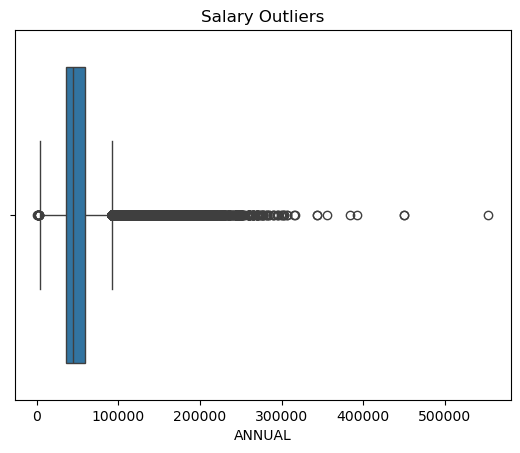

In [18]:
plt.figure()
sns.boxplot(x=df['ANNUAL'])
plt.title("Salary Outliers")
plt.show()

In [19]:
Q1 = df['ANNUAL'].quantile(0.25)
Q3 = df['ANNUAL'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['ANNUAL'] >= lower) & (df['ANNUAL'] <= upper)]

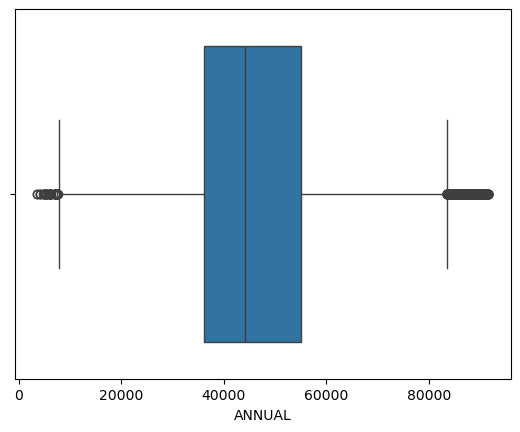

In [20]:
sns.boxplot(x=df['ANNUAL'])
plt.show()

In [21]:
df['ANNUAL'].mean()
df['ANNUAL'].median()

44193.42

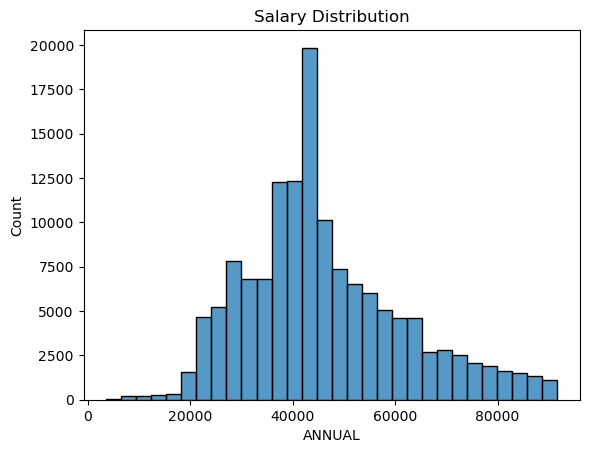

In [22]:
sns.histplot(df['ANNUAL'], bins=30)
plt.title("Salary Distribution")
plt.show()

In [23]:
df.groupby('GENDER')['ANNUAL'].mean()

GENDER
FEMALE             44633.498641
MALE               48183.126733
Name: ANNUAL, dtype: float64

In [24]:
df.groupby('ETHNICITY')['ANNUAL'].mean()

ETHNICITY
AM INDIAN          46007.459096
ASIAN              53447.497608
BLACK              42047.087299
HISPANIC           44722.837310
OTHER              42985.187824
WHITE              48996.860959
Name: ANNUAL, dtype: float64

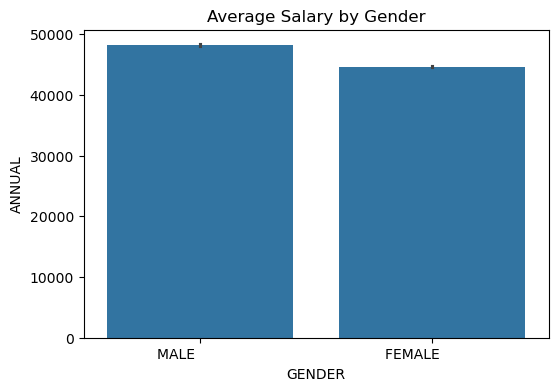

In [25]:
plt.figure(figsize=(6,4))
sns.barplot(x='GENDER', y='ANNUAL', data=df)
plt.title("Average Salary by Gender")
plt.show()

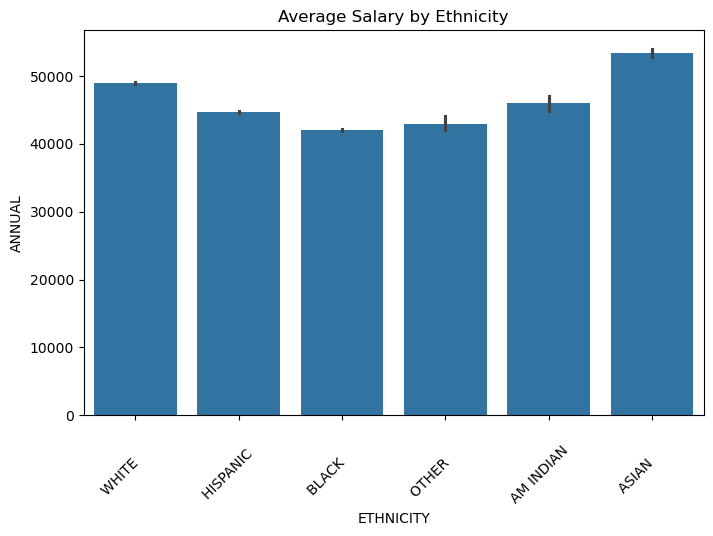

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(x='ETHNICITY', y='ANNUAL', data=df)
plt.title("Average Salary by Ethnicity")
plt.xticks(rotation=45)
plt.show()

In [27]:
print("Conclusion:")
print("1. Salary distribution is slightly right-skewed.")
print("2. Presence of outliers in high salary range.")
print("3. Males have slightly higher average salary than females.")
print("4. Salary varies across ethnic groups, with Asians having highest average.")

Conclusion:
1. Salary distribution is slightly right-skewed.
2. Presence of outliers in high salary range.
3. Males have slightly higher average salary than females.
4. Salary varies across ethnic groups, with Asians having highest average.
